# CMI コンペティション 特徴量エンジニアリング検証

このノートブックでは、`preprocessing.py`の機能を使用して包括的な特徴量エンジニアリングを行います。

## 目次
1. ライブラリのインポート・データ読み込み
2. 基本統計量の計算
3. ピーク特徴量の計算
4. FFTバンドエネルギー計算
5. IMU世界座標系変換
6. 欠損センサーフラグ
7. TDA統計（Persistence Image）
8. AutoEncoder再構成誤差
9. Wavelet特徴量計算
10. 利き手反転正規化
11. 特徴量の統合・可視化
12. 結果の評価


## Step 1: ライブラリのインポート・データ読み込み


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import yaml
warnings.filterwarnings('ignore')

# preprocessing.pyをインポート
sys.path.append('../src')
from utils.preprocessing import *

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'

print("ライブラリ読み込み完了")

# データファイルの読み込み
# 1) 設定読み込み
with open("../config/config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# ToFカラム自動展開
data_dir = cfg["data_dir"]
cache_dir = cfg["cache_dir"]
train_path = Path("../") / Path(data_dir) / "train.csv"
demographics_path = Path("../") / Path(data_dir) / "train_demographics.csv"
test_path = Path("../") / Path(data_dir) / "test.csv"
test_demographics_path = Path("../") / Path(data_dir) / "test_demographics.csv"

print(f"データパス確認:")
print(f"  train.csv: {train_path.exists()}")
print(f"  train_demographics.csv: {demographics_path.exists()}")
print(f"  test.csv: {test_path.exists()}")
print(f"  test_demographics.csv: {test_demographics_path.exists()}")

# データ読み込み
if train_path.exists():
    print(f"📂 データを読み込み中: {train_path}")
    train = pd.read_csv(train_path)
    print(f"✅ Train データ読み込み完了: {train.shape}")
else:
    print(f"❌ データファイルが見つかりません: {train_path}")
    raise FileNotFoundError(f"データファイルが見つかりません: {train_path}")

if demographics_path.exists():
    print(f"📂 人口統計データを読み込み中: {demographics_path}")
    demographics = pd.read_csv(demographics_path)
    print(f"✅ Demographics データ読み込み完了: {demographics.shape}")
else:
    print(f"❌ データファイルが見つかりません: {demographics_path}")
    raise FileNotFoundError(f"データファイルが見つかりません: {demographics_path}")

# データ結合
train_with_demographics = train.merge(demographics, on='subject', how='left')
print(f"✅ データ結合完了: {train_with_demographics.shape}")

# 基本情報表示
print("\n=== データ基本情報 ===")
print(f"訓練データサイズ: {train_with_demographics.shape}")
print(f"Demographics columns: {[col for col in train_with_demographics.columns]}")
print(f"ユニークな被験者数: {train_with_demographics['subject'].nunique()}")
print(f"ユニークなシークエンス数: {train_with_demographics['sequence_id'].nunique()}")
print(f"ユニークなジェスチャー数: {train_with_demographics['gesture'].nunique()}")
print(f"利き手分布:")
print(train_with_demographics['handedness'].value_counts())
print(train_with_demographics.head())


ライブラリ読み込み完了
データパス確認:
  train.csv: True
  train_demographics.csv: True
  test.csv: True
  test_demographics.csv: True
📂 データを読み込み中: ../data/train.csv
✅ Train データ読み込み完了: (574945, 341)
📂 人口統計データを読み込み中: ../data/train_demographics.csv
✅ Demographics データ読み込み完了: (81, 8)
✅ データ結合完了: (574945, 348)

=== データ基本情報 ===
訓練データサイズ: (574945, 348)
Demographics columns: ['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', '

## Step 2: センサーカラムの特定とデータ前処理




| ステージ              | 具体的処理                                                                                     | 主なファイル／関数          |
| ----------------- | ----------------------------------------------------------------------------------------- | ------------------ |
| **① 入力データ**       | `train.csv`（332 センサ列＋メタ）<br>`train_demographics.csv`                                      | ―                  |
| **② 事前マスク**       | `clean_sensor_missing_values()`<br>‐ Accelerometer: 極端値→NaN<br>‐ ToF: 255↑＆-2↓→NaN（-1は保持） | `preprocessing.py` |
| **③ 利き手補正**       | `handedness_correction_v2()`（IMU左右反転）                                                     | 〃                  |
| **④ ToF 水平ミラー**   | 左利き行だけ `mirror_tof_rows()`                                                                | 〃                  |
| **⑤ 欠測補間**        | `clean_missing_sensor_data_parallel_disk()`<br>グループ単位（subject, sequence\_id）で並列処理         | `preprocessing.py` |
|   └ Accelerometer | 線形補間 (limit = 3 f)                                                                        |                    |
|   └ Rotation      | **SLERP** 補間 (limit = 120 f)                                                              |                    |
|   └ ToF\_Sensor   | −1→NaN→線形補間 (limit = 4 f)→残りNaNを-1復元                                                      |                    |
|   └ Thermal       | 線形補間 (limit = 120 f)                                                                      |                    |
| **⑥ 出力**          | 欠測を埋めた `train_final`（同じ列数）<br>キャッシュ: `cache/processed/train_final.parquet`                | ―                  |

### 重要パラメータ

```python
FPS          = 64          # 1 秒 ≒ 64 フレーム
interp_params = {
    "Accelerometer": {"method":"linear", "limit":3},
    "Rotation"     : {"method":"slerp" , "limit":120},
    "ToF_Sensor"   : {"method":"linear", "limit":4 , "fill_value":-1},
    "Thermal"      : {"method":"linear", "limit":120},
}
group_cols = ("subject", "sequence_id")
time_col   = "sequence_counter"
```



In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
CMI ─ 前処理パイプライン（cache 対応 + world-frame 加速度）
"""

import os, sys, multiprocessing, yaml
from pathlib import Path
import pandas as pd
sys.path.append("../")

# ───────────────────────────────────────────────
# 0. path & util import
# ───────────────────────────────────────────────
sys.path.append("../")
from src.utils.preprocessing import (
    clean_sensor_missing_values,
    clean_missing_sensor_data_parallel_disk,
    handedness_correction_v2,
    mirror_tof_rows,
)
from src.utils.imu import add_world_acc_features

print("=== キャッシュ対応パイプライン開始 ===")

# ───────────────────────────────────────────────
# 1. 設定読み込み
# ───────────────────────────────────────────────
with open("../config/config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)

with open("../config/interp_params.yaml", "r") as f:
    interp_params = yaml.safe_load(f)
    
data_dir   = Path("../") / cfg["data_dir"]
train_path = data_dir / "train.csv"
demo_path  = data_dir / "train_demographics.csv"

cache_root  = Path.cwd().parent / cfg.get("cache_dir", "cache") / "processed"
cache_root.mkdir(parents=True, exist_ok=True)
train_cache = cache_root / "train_final.parquet"
print(f"キャッシュパス: {train_cache}")

n_jobs = max(1, multiprocessing.cpu_count() // 2)
print(f"使用コア数: {n_jobs}")

# ───────────────────────────────────────────────
# 2. キャッシュ or 生データ読み込み
# ───────────────────────────────────────────────
if train_cache.exists():
    print("✅ キャッシュ検出 → 読み込み中")
    train_final = pd.read_parquet(train_cache)

else:
    print("🛠 キャッシュ未検出 → 前処理開始")

    # 2-1 原データ + demographics 結合
    train_raw = pd.read_csv(train_path)
    demographics = pd.read_csv(demo_path)
    train_with_demo = train_raw.merge(demographics, on="subject", how="left")

    # 2-2 欠損マスク
    acc_cols = [c for c in train_with_demo.columns if c.startswith("acc_")]
    rot_cols = [c for c in train_with_demo.columns if c.startswith("rot_")]
    tof_cols = [c for c in train_with_demo.columns if c.startswith("tof_")]
    thm_cols = [c for c in train_with_demo.columns if c.startswith("thm_")]
    sensor_type_groups = {
        "Accelerometer": acc_cols,
        "Rotation":      rot_cols,
        "ToF_Sensor":    tof_cols,
        "Thermal":       thm_cols,
    }

    train_masked = clean_sensor_missing_values(train_with_demo, sensor_type_groups)
    print("欠損マスク完了")

    # 2-3 欠損補間
    train_interp = clean_missing_sensor_data_parallel_disk(
        train_masked,
        sensor_type_groups=sensor_type_groups,
        interp_params=interp_params, 
        group_cols=("subject", "sequence_id"),
        time_col="sequence_counter",
        n_jobs=n_jobs,
        keep_tmp=False,
        keep_cols=list(demographics.columns),
    )
    print("時系列補間完了")

    # 2-4 利き手補正 + ToF 水平ミラー
    train_norm = handedness_correction_v2(train_interp)
    left_idx   = train_norm["handedness"] == 0
    train_mirror = train_norm.copy()
    train_mirror.loc[left_idx, tof_cols] = mirror_tof_rows(
        train_norm.loc[left_idx, :], tof_cols)
    print("利き手補正 + ToF ミラー完了")

    # 2-5 ワールド加速度 & 線形加速度  ★NEW
    train_final = add_world_acc_features(train_mirror)
    print("ワールド加速度列を追加")

    # 2-6 キャッシュ保存
    train_final.to_parquet(train_cache, index=False)
    print(f"✅ すべて完了 & キャッシュ保存: {train_cache}")

    # 2-7 動作確認 head
    debug_cols = [
        "sequence_id", "sequence_counter", "handedness",
        "acc_y", "acc_z",
        "acc_w_x", "acc_w_y", "acc_w_z",
        "lin_acc_x", "lin_acc_y", "lin_acc_z",
        "tof_1_v0", "tof_1_v1",
    ]
    display(train_final.loc[:, debug_cols].head())

# ───────────────────────────────────────────────
# 3. 結果概要
# ───────────────────────────────────────────────
print("\n=== 処理結果 ===")
print(f"Shape : {train_final.shape}")
print(f"Columns added: {[c for c in train_final.columns if c.startswith(('acc_w','lin_acc'))][:6]} ...")


=== キャッシュ対応パイプライン開始 ===
キャッシュパス: /mnt/c/Users/ShunK/works/CMI_comp/cache/processed/train_final.parquet
使用コア数: 6
✅ キャッシュ検出 → 読み込み中

=== 処理結果 ===
Shape : (574945, 348)
Columns added: ['acc_w_x', 'acc_w_y', 'acc_w_z', 'lin_acc_x', 'lin_acc_y', 'lin_acc_z'] ...


## 確認



In [3]:
from IPython.display import HTML, display
import pandas as pd

def show_steps_side_by_side(
    steps: dict[str, pd.DataFrame],
    cols: list[str],
    *,
    n_rows: int = 5,
    seq_id: str | None = None,
    query: str | None = None,
    na_color: str = "tomato",
):
    """
    steps  : {"ラベル": DataFrame, ...}
    cols   : 表示対象列
    n_rows : head の行数
    seq_id : 'sequence_id' でフィルタ（None なら全件）
    query  : pandas.DataFrame.query 互換の条件式
    """
    html_parts = []
    for name, df in steps.items():
        # --- 条件フィルタ -------------------------------------------
        _df = df
        if seq_id is not None:
            _df = _df[_df["sequence_id"] == seq_id]
        if query is not None:
            _df = _df.query(query, engine="python")
        # ------------------------------------------------------------

        sty = (
            _df.loc[:, cols]
               .head(n_rows)
               .style
               .set_caption(f"<b>{name}</b>")
               .format(precision=3, na_rep="NaN")
               .highlight_null(color=na_color)
               .set_table_attributes(
                   'class="dataframe" '
                   'style="display:inline-block; margin:0 1em 1em 0;"'
               )
        )
        html_parts.append(sty.to_html())

    display(HTML("".join(html_parts)))



# ------------------------------------------------------------

cols = ["sequence_id","sequence_counter","handedness",
        "acc_y","acc_z","tof_1_v0","tof_1_v1"]

steps = {
    "原データ":          train_with_demographics,
    "欠損マスク後":      train_masked,
    "IMU利き手補正後":   train_mirror,
    "補間後":            train_final,
}

# 1) 行数だけ指定
# show_steps_side_by_side(steps, cols, n_rows=3)

# # 2) 特定 sequence_id だけ
show_steps_side_by_side(steps, cols, seq_id="SEQ_000046", n_rows=7)

# 3) 任意の条件クエリ（例: ToF が -1 の行）
show_steps_side_by_side(steps, cols, query="handedness == 0", n_rows=10)

# # 4) sequence もクエリも併用
# show_steps_side_by_side(
#     steps, cols,
#     seq_id="SEQ_000284",
#     query="handedness == 1 & acc_y.abs() > 10",
#     n_rows=20,
#     na_color="gold"
# )



NameError: name 'train_masked' is not defined

In [4]:
# === quick_sensor_report ====================================
import numpy as np, pandas as pd
from IPython.display import display

def quick_sensor_report(df: pd.DataFrame) -> pd.DataFrame:
    """各センサ prefix ごとの min / max / NaN 率 / 四元数ノルム逸脱を集計"""
    report = []
    for pre in ("acc", "rot", "acc_w", "lin_acc", "tof", "thm"):
        cols = [c for c in df.columns if c.startswith(pre)]
        if not cols:
            continue
        arr = df[cols].to_numpy()
        nan_ratio = np.isnan(arr).mean()
        min_v, max_v = np.nanmin(arr), np.nanmax(arr)
        norm_err = np.nan
        if pre == "rot":
            q = arr.reshape(-1, 4)
            norm_err = np.abs(np.linalg.norm(q, axis=1) - 1).max()
        report.append(dict(sensor=pre, min=min_v, max=max_v,
                           nan_ratio=f"{nan_ratio:.3%}",
                           norm_error=f"{norm_err:.3e}"))

    rep = pd.DataFrame(report).set_index("sensor").sort_index()
    return rep

display(quick_sensor_report(train_final))


,min,max,nan_ratio,norm_error
sensor,,,,
acc,-34.585938,38.328125,0.000%,nan
acc_w,-30.127451,34.692646,0.000%,nan
lin_acc,-38.972295,33.290070,0.000%,nan
rot,-0.999871,1.000000,0.000%,2.220e-16
thm,-0.370413,39.588390,2.106%,nan
tof,-1.000000,249.000000,0.000%,nan


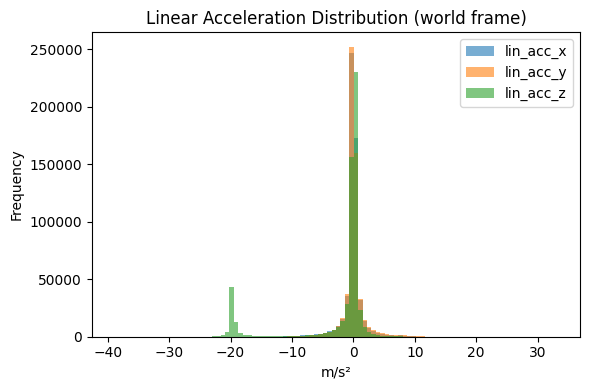

In [5]:
# === lin_acc distribution ===================================
import matplotlib.pyplot as plt
import numpy as np

ax = train_final[["lin_acc_x","lin_acc_y","lin_acc_z"]].plot(
    kind="hist", bins=100, alpha=0.6, figsize=(6,4), sharex=True)
ax.set_title("Linear Acceleration Distribution (world frame)")
ax.set_xlabel("m/s²"); plt.tight_layout()
plt.show()


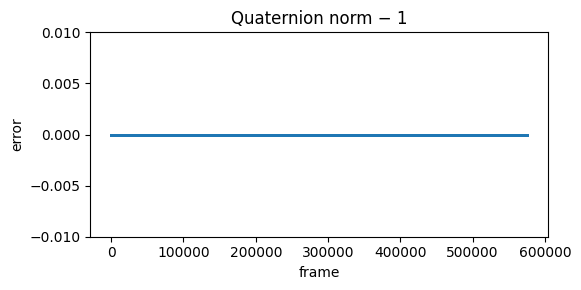

In [6]:
# === quaternion norm scatter =================================
import matplotlib.pyplot as plt
import numpy as np

q = train_final[["rot_w","rot_x","rot_y","rot_z"]].to_numpy()
norm_err = np.linalg.norm(q, axis=1) - 1
plt.figure(figsize=(6,3))
plt.scatter(range(len(norm_err)), norm_err, s=1)
plt.title("Quaternion norm − 1"); plt.ylabel("error"); plt.xlabel("frame")
plt.ylim(-1e-2, 1e-2); plt.tight_layout(); plt.show()


TypeError: Image data of dtype object cannot be converted to float

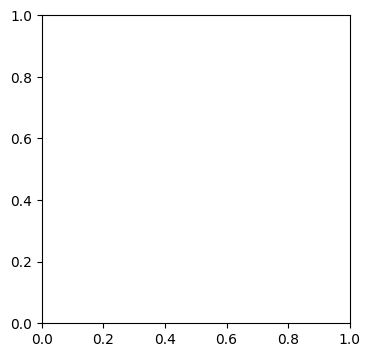

In [7]:
# === ToF heatmap (sensor 1) =================================
import matplotlib.pyplot as plt
import numpy as np

def plot_tof_heatmap(df: pd.DataFrame, seq_id: str, frame: int = 0, sensor: int = 1):
    row = df[(df.sequence_id == seq_id) & (df.sequence_counter == frame)].iloc[0]
    vals = row[[f"tof_{sensor}_v{i}" for i in range(64)]].to_numpy().reshape(8,8)
    plt.figure(figsize=(4,4))
    plt.imshow(vals, cmap="viridis", origin="lower")
    plt.colorbar(label="distance (mm)")
    plt.title(f"ToF sensor {sensor} – {seq_id} frame {frame}")
    plt.axis("off"); plt.show()

plot_tof_heatmap(train_final, seq_id="SEQ_000046", frame=0)


### ✅ チェック 1 / 4 — 重力方向の自動推定 vs. クォータニオン重力


In [8]:
import numpy as np
import pandas as pd

def get_static_mask(df: pd.DataFrame, th=0.3):
    lin = df[['lin_acc_x', 'lin_acc_y', 'lin_acc_z']].to_numpy()
    return (np.linalg.norm(lin, axis=1) < th)
from scipy.spatial.transform import Rotation as R

def rotate_acc_to_world(df: pd.DataFrame, mask):
    # 加速度 (device frame)
    acc_dev = df.loc[mask, ['acc_x','acc_y','acc_z']].to_numpy()
    # rot_{w,x,y,z} → (x,y,z,w)
    quat = df.loc[mask, ['rot_x','rot_y','rot_z','rot_w']].to_numpy()
    acc_world = R.from_quat(quat).apply(acc_dev)
    return acc_world
def seq_gravity_check(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for seq, gdf in df.groupby('sequence_id'):
        mask = get_static_mask(gdf)
        if mask.sum() < 10:            # 静止点が少ないシーケンスはスキップ
            continue
        g_est = rotate_acc_to_world(gdf, mask).mean(axis=0)      # 推定重力
        # 角度誤差（deg）
        cos_θ = g_est @ np.array([0,0,-9.81]) / (np.linalg.norm(g_est)*9.81)
        θ = np.degrees(np.arccos(np.clip(cos_θ, -1, 1)))
        rows.append(dict(sequence_id=seq,
                         g_x=g_est[0], g_y=g_est[1], g_z=g_est[2],
                         angle_deg=θ))
    return pd.DataFrame(rows)
g_report = seq_gravity_check(train_final)
print(g_report.describe())      # 分布サマリ
print(g_report.sort_values('angle_deg', ascending=False).head())


               g_x          g_y          g_z    angle_deg
count  3886.000000  3886.000000  3886.000000  3886.000000
mean      0.005422     0.000359     9.879447   179.760688
std       0.035006     0.035013     0.082641     0.162205
min      -0.194759    -0.188071     9.606515   178.748618
25%      -0.014067    -0.020062     9.817551   179.677474
50%       0.005881    -0.000417     9.875667   179.796666
75%       0.025038     0.020085     9.943657   179.880208
max       0.198439     0.201896    10.084938   179.995971
     sequence_id       g_x       g_y       g_z   angle_deg
1076  SEQ_018203  0.000025  0.000701  9.980399  179.995971
3160  SEQ_053459  0.000742 -0.000544  9.739577  179.994589
605   SEQ_010253 -0.000677 -0.000857  9.911707  179.993686
272   SEQ_004601 -0.001134 -0.000318  9.870305  179.993163
840   SEQ_014343  0.000975 -0.001008  9.755442  179.991766


In [9]:
def check_frame_integrity(df: pd.DataFrame) -> pd.DataFrame:
    rep = []
    for seq, gdf in df.groupby('sequence_id'):
        diff = gdf['sequence_counter'].diff().fillna(1).astype(int)
        # 欠落 ( >1 ), 逆順 ( <0 ), 重複 (==0)
        n_gap   = (diff > 1).sum()
        n_dup   = (diff == 0).sum()
        n_back  = (diff < 0).sum()
        if n_gap or n_dup or n_back:        # 問題あるものだけ記録
            rep.append(dict(sequence_id=seq,
                            gaps=n_gap, dups=n_dup, backward=n_back))
    return pd.DataFrame(rep)

frame_report = check_frame_integrity(train_final)
print(f'異常シーケンス数: {len(frame_report)} / {train_final.sequence_id.nunique()}')
display(frame_report.head())


異常シーケンス数: 0 / 8151


""


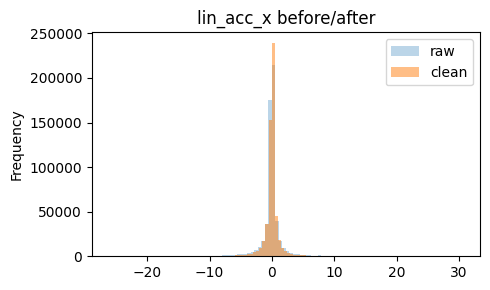

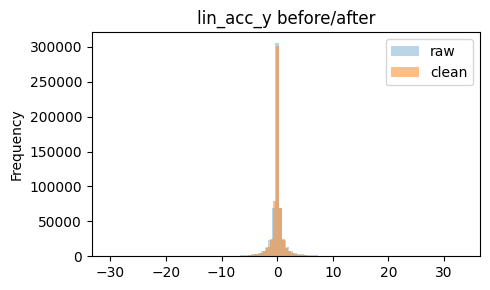

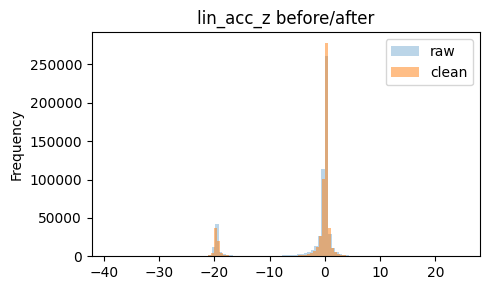

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation

def mark_spikes(df: pd.DataFrame,
                cols: list[str],
                th_abs: float | None = None,
                k: float = 5.0,  # Hampel k σ
                wnd: int = 11):  # 奇数
    half = wnd // 2
    flags = np.zeros(len(df), dtype=bool)
    for c in cols:
        x = df[c].to_numpy()
        # Hampel フィルタ
        med = pd.Series(x).rolling(wnd, center=True, min_periods=1).median()
        mad = pd.Series(x).rolling(wnd, center=True, min_periods=1) \
                          .apply(median_abs_deviation, raw=True)
        mask = np.abs(x - med) > k * (mad + 1e-6)
        if th_abs is not None:
            mask |= np.abs(x) > th_abs
        flags |= mask
        # 値の補正: 線形補間 (前後の非スパイク値で)
        x[mask] = np.interp(np.flatnonzero(mask),
                            np.flatnonzero(~mask), x[~mask])
        df[c] = x
    return flags

# --- 適用例 ----------------------------------------------
train_clean = train_final.copy()

flag_acc  = mark_spikes(train_clean, ['acc_x','acc_y','acc_z'],
                        th_abs=39.2)
flag_lin  = mark_spikes(train_clean, ['lin_acc_x','lin_acc_y','lin_acc_z'],
                        th_abs=29.4)
flag_gyro = mark_spikes(train_clean, ['acc_w_x','acc_w_y','acc_w_z'],
                        th_abs=np.deg2rad(2000))

# フラグを 1/0 の新列として追加
train_clean['is_spike'] = (flag_acc | flag_lin | flag_gyro).astype(np.int8)
# スパイク除去前後の比較ヒスト
import matplotlib.pyplot as plt

for ax in ['lin_acc_x','lin_acc_y','lin_acc_z']:
    plt.figure(figsize=(5,3))
    train_final[ax].plot(kind='hist', bins=100, alpha=0.3, label='raw')
    train_clean[ax].plot(kind='hist', bins=100, alpha=0.5, label='clean')
    plt.title(f'{ax} before/after')
    plt.legend(); plt.tight_layout()
    plt.show()

In [12]:
tof_cols = [c for c in train_clean.columns if c.startswith('tof_')]

# −1 → NaN
train_clean[tof_cols] = train_clean[tof_cols].replace(-1, np.nan)

# 時間方向線形補間
train_clean[tof_cols] = (
    train_clean.groupby('sequence_id')[tof_cols]
               .apply(lambda g: g.interpolate(limit_direction='both'))
)
# まだ NaN が残る（全欠落列など）場合は sequence 平均で埋め
train_clean[tof_cols] = (
    train_clean.groupby('sequence_id')[tof_cols]
               .transform(lambda x: x.fillna(x.mean()))
)


TypeError: incompatible index of inserted column with frame index